In [1]:
# importing required libraries 

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import torch 
import os
from tqdm import tqdm
from pathlib import Path
import io
from PIL import UnidentifiedImageError

## opening it in a image embeddings dictionary

In [2]:
import pickle
from pathlib import Path
cwd=os.getcwd()
curr_dir=Path(cwd).parent
embedding_dir=os.path.join(curr_dir,"embeddings")
path = os.path.join(embedding_dir, "image_embeddings.pickle")

with open(path,"rb") as handle:
        image_embeddings=pickle.load(handle)



In [3]:

test_path = os.path.join(embedding_dir, "test_image_embeddings.pickle")
with open(test_path,"rb") as handle:
    test_image_embeddings=pickle.load(handle)




### Creating array of embeddings and images

In [4]:
vectors=[]
images=[]
for image,embedding in image_embeddings.items():
    vectors.append(embedding)
    images.append(image)
images[:10]


['d:\\cdc project\\images\\property_0.png',
 'd:\\cdc project\\images\\property_1.png',
 'd:\\cdc project\\images\\property_2.png',
 'd:\\cdc project\\images\\property_3.png',
 'd:\\cdc project\\images\\property_4.png',
 'd:\\cdc project\\images\\property_5.png',
 'd:\\cdc project\\images\\property_6.png',
 'd:\\cdc project\\images\\property_7.png',
 'd:\\cdc project\\images\\property_8.png',
 'd:\\cdc project\\images\\property_9.png']

### Creating array of embeddings and test_images

In [5]:
test_vectors=[]
test_images=[]
for image,embedding in test_image_embeddings.items():
    test_vectors.append(embedding)
    test_images.append(image)
test_images[:10]

['d:\\cdc project\\test_images\\property_0.png',
 'd:\\cdc project\\test_images\\property_1.png',
 'd:\\cdc project\\test_images\\property_2.png',
 'd:\\cdc project\\test_images\\property_3.png',
 'd:\\cdc project\\test_images\\property_4.png',
 'd:\\cdc project\\test_images\\property_5.png',
 'd:\\cdc project\\test_images\\property_6.png',
 'd:\\cdc project\\test_images\\property_7.png',
 'd:\\cdc project\\test_images\\property_8.png',
 'd:\\cdc project\\test_images\\property_9.png']

### opening our dataset

In [6]:
import pandas as pd 
data_dir=os.path.join(curr_dir,"data")
df=pd.read_csv(os.path.join(data_dir,"train(1).csv"))
df_test=pd.read_csv(os.path.join(data_dir,"test2(test(1)).csv"))

In [7]:
from sklearn.preprocessing import StandardScaler

spatial_features = [
    "sqft_living",
    "sqft_living15",
    "sqft_lot",
    "sqft_lot15",
    "lat",
    "long",
    "sqft_above",
    "sqft_basement"
]

scaler=StandardScaler()
df[spatial_features]=scaler.fit_transform(df[spatial_features])
df_test[spatial_features]=scaler.fit_transform(df_test[spatial_features])


### creating our dataset of tabular and images

In [8]:
y=np.log1p(df["price"].values)
X_tabular=df.drop(columns=["price","date","id"]).values

X_images=np.array(vectors)

assert len(X_tabular) == len(X_images)

### Splitting our datasets with 80 train and 20 val

In [9]:
from sklearn.model_selection import train_test_split

X_tabular_train,X_tabular_val,X_images_train,X_images_val,y_train,y_val=train_test_split(
    X_tabular,
    X_images,
    y,
    test_size=0.2,
    random_state=42
)

### Training our tabular data on sgboost with hyperparameter tuning

In [10]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score,root_mean_squared_error
xgb_tabular = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.09,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)
xgb_tabular.fit(X_tabular_train,y_train)
tabular_pred_train = xgb_tabular.predict(X_tabular_train)
tabular_pred_val = xgb_tabular.predict(X_tabular_val)

print("XGB Tabular")
print(f"MAE:", mean_absolute_error(y_val, tabular_pred_val))
print(f"RMSE:", root_mean_squared_error(y_val, tabular_pred_val))
print("R² :", r2_score(y_val, tabular_pred_val))


XGB Tabular
MAE: 0.11906840192077561
RMSE: 0.16546856915742134
R² : 0.9007810068938288


### Plotting important features producing these scores


{'bedrooms': np.float32(0.0034796745), 'bathrooms': np.float32(0.00849753), 'sqft_living': np.float32(0.11182764), 'sqft_lot': np.float32(0.008128884), 'floors': np.float32(0.007136809), 'waterfront': np.float32(0.068321586), 'view': np.float32(0.053744975), 'condition': np.float32(0.014891936), 'grade': np.float32(0.46909702), 'sqft_above': np.float32(0.012431143), 'sqft_basement': np.float32(0.0052554137), 'yr_built': np.float32(0.016236799), 'yr_renovated': np.float32(0.012232175), 'zipcode': np.float32(0.016905556), 'lat': np.float32(0.14057712), 'long': np.float32(0.021215722), 'sqft_living15': np.float32(0.019383378), 'sqft_lot15': np.float32(0.010636579)}


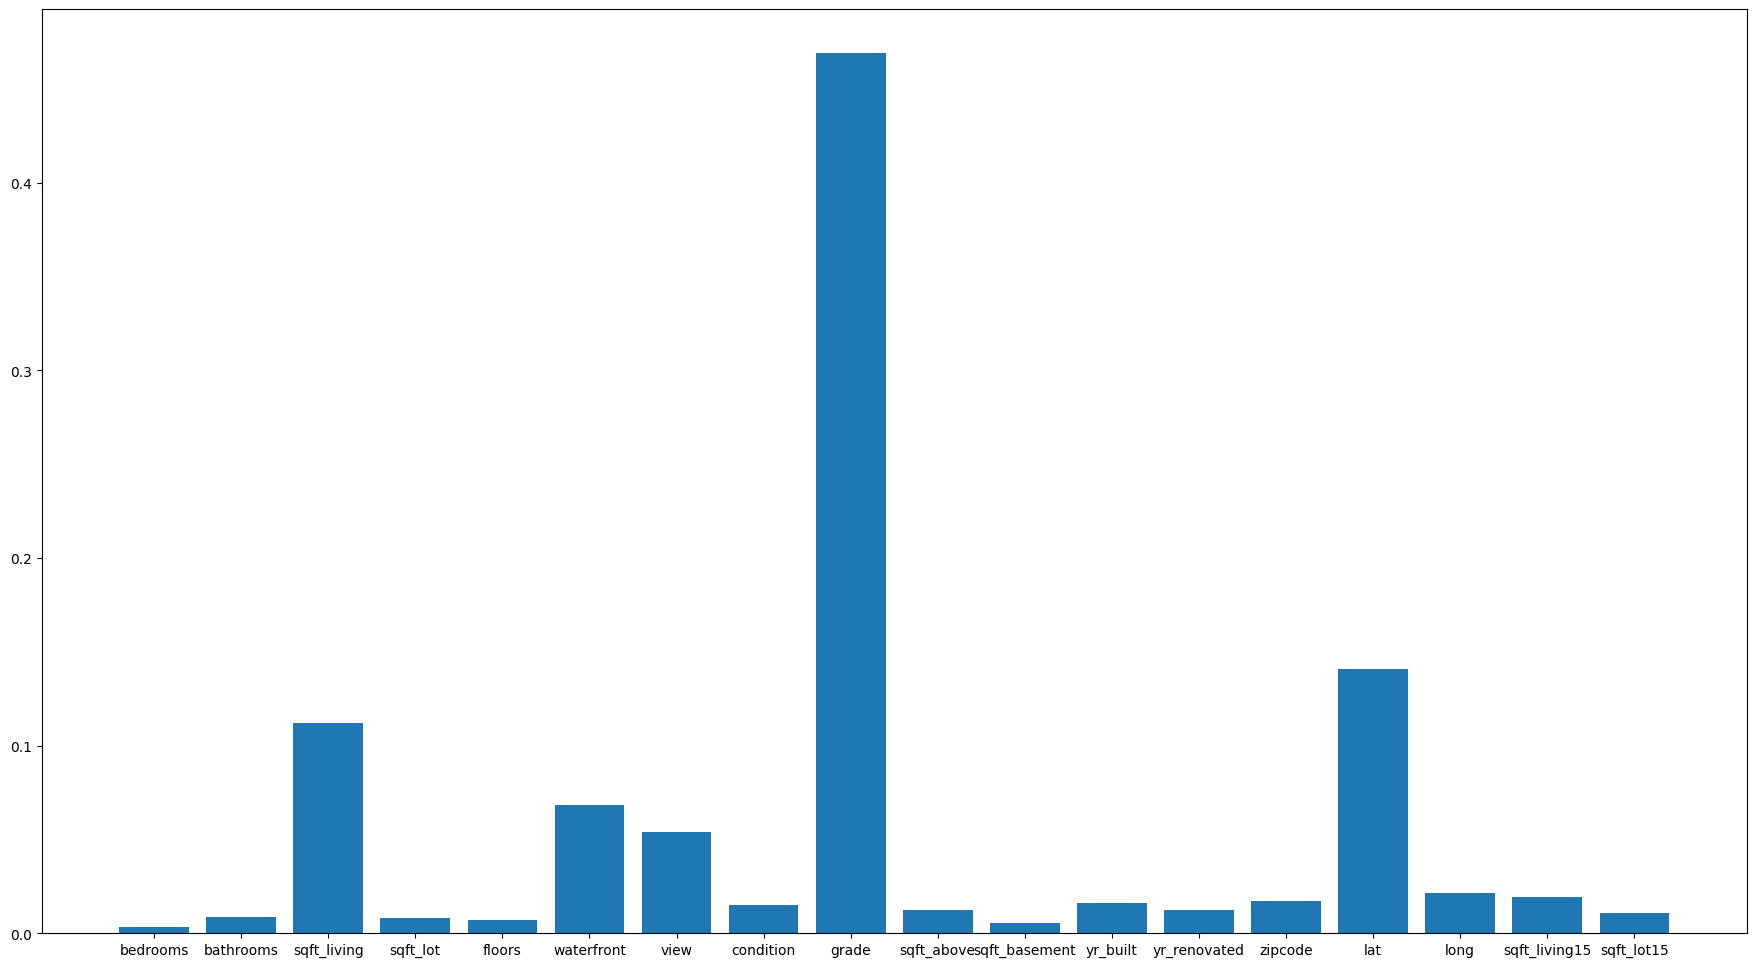

In [11]:
import matplotlib.pyplot as plt
features=df.drop(columns=["price","date","id"]).columns
features_value=xgb_tabular.feature_importances_
visulaizer={}
for i in range(len(features)) :
    visulaizer[features[i]]=features_value[i]
print(visulaizer)
plt.figure(figsize=(22,12))
plt.bar(visulaizer.keys(),visulaizer.values())
plt.grid
plt.show()


### Writing our neural network for image embeddings

In [12]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
device = "cuda" if torch.cuda.is_available() else "cpu"

class ImageNN(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(d,128),
            nn.ReLU(),
            nn.Linear(128,1)
        )
    def forward(self,x):
        return self.net(x).squeeze()

In [13]:
def train_nn(model, X, y, epochs=50):
    model.to(device)
    opt=torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn=nn.MSELoss()

    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )
    dl = DataLoader(ds, batch_size=64, shuffle=True)
    
    loss_array=[]
    for _ in range(epochs):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb), yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
        loss_array.append(loss.sum().detach().numpy())
    return (loss_array)

### applying pca on our embeddings

In [14]:
from sklearn.decomposition import PCA

PCA_DIM = 128  

pca = PCA(
    n_components=PCA_DIM,
    random_state=42
)

X_images_train_pca = pca.fit_transform(X_images_train)
X_images_val_pca = pca.transform(X_images_val)

print("Explained variance:", pca.explained_variance_ratio_.sum())

Explained variance: 0.9112903


### plotting training loss 

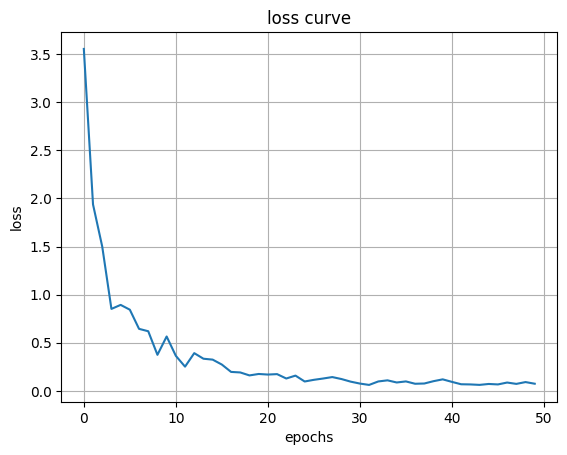

In [22]:
d = X_images_train_pca.shape[1]
image_model=ImageNN(d).to(device)
history=train_nn(image_model,X_images_train_pca,y_train)
plt.plot(history)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("loss curve")
plt.grid()
plt.show()


### Generating predictions by converting our dataset to tensor

In [16]:
image_model.eval()
X_image_train_pca_tensor=torch.tensor(X_images_train_pca,dtype=torch.float32).to(device)
X_image_val_pca_tensor = torch.tensor(X_images_val_pca, dtype=torch.float32).to(device)

with torch.no_grad():
    image_pred_train=image_model(X_image_train_pca_tensor).cpu().numpy()
    image_pred_val = image_model(X_image_val_pca_tensor).cpu().numpy()

print("Image NN")
print("MAE:", mean_absolute_error(y_val, image_pred_val))
print("RMSE:", np.sqrt(np.mean((y_val - image_pred_val) ** 2)))
print("R² :", r2_score(y_val, image_pred_val))


Image NN
MAE: 0.3655947478363392
RMSE: 0.47826460496845674
R² : 0.17110355937136645


### Stacking our both models for final model

In [17]:
X_stack_train = np.column_stack([tabular_pred_train, image_pred_train])
X_stack_val = np.column_stack([tabular_pred_val, image_pred_val])

In [18]:
from sklearn.linear_model import LinearRegression

meta = LinearRegression()
meta.fit(X_stack_train, y_train)

final_pred_linear = meta.predict(X_stack_val)

In [19]:
print("Meta Fusion")
print(f"MAE:", mean_absolute_error(y_val, final_pred_linear))
print(f"RMSE:", root_mean_squared_error(y_val, final_pred_linear))
print("R² :", r2_score(y_val, final_pred_linear))


Meta Fusion
MAE: 0.11877384183004848
RMSE: 0.1646551166609188
R² : 0.9017541409558251


### Sending our test_data through our pipeline 

In [20]:
X_images_test=np.array(test_vectors) 

X_images_pca_test = pca.fit_transform(X_images_test)

x_tab_test = df_test.drop(columns=["date","id"]).values

tabular_pred_test = xgb_tabular.predict(x_tab_test)

X_image_pca_test_tensor=torch.tensor(X_images_pca_test,dtype=torch.float32).to(device)

with torch.no_grad():
	image_pred_test = image_model(X_image_pca_test_tensor).cpu().detach().numpy() 

X_stack_test = np.column_stack([tabular_pred_test, image_pred_test]) 

final_test_pred = meta.predict(X_stack_test)
## converting back to normal values from log 
final_price_pred = np.expm1(final_test_pred)


In [21]:
final_price_pred=final_price_pred.astype(int)
final_price_pred

array([ 361312,  831337, 1047674, ...,  271073, 1714676,  304643],
      shape=(5404,))

In [35]:
assert len(final_price_pred) == len(df_test), "final_price_pred length != number of test rows"
## creating submission.csv
df_submission = df_test[['id']].copy()
df_submission['prices'] = final_price_pred
df_submission.to_csv("submission.csv", index=False)